# 수입식품 출연과제
## 데이터마이닝
<img src = 'https://images.unsplash.com/photo-1523848309072-c199db53f137?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxjb2xsZWN0aW9uLXBhZ2V8MTV8MjM4MzU3MHx8ZW58MHx8fHw%3D&auto=format&fit=crop&w=500&q=60' >

In [148]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings('ignore')
# Imports
import pandas as pd
import numpy as np
import seaborn as sns; sns.set()
import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [149]:
def summary(df) :
    tf = pd.DataFrame({'데이터형태(dtypes)' : df.dtypes,
                       '결측치 수(null)' : df.isnull().sum(),
                       '결측치 비율(%)' : (df.isnull().sum()/len(df)).round(2),
                       '고유값 수(nunique)' : df.nunique(),
                      })
    for col in tf.index:
        tf.loc[col, '자료 내용(contents)'] = str(df[col].unique()[0:5])
        
    return tf

# Obtain data

In [150]:
path =r'D:\smart food\data'
import glob
glob.glob(path + '/*.pkl')

['D:\\smart food\\data\\20220310_조상구_무작위추출결과(21년 4분기).pkl',
 'D:\\smart food\\data\\20220310_조상구_수입실적 기본정보(21년 4분기).pkl',
 'D:\\smart food\\data\\df_0524.pkl',
 'D:\\smart food\\data\\paper.pkl',
 'D:\\smart food\\data\\가공식품_수입식품(16년~21년).pkl',
 'D:\\smart food\\data\\농.임산물_수입식품(16년~21년).pkl',
 'D:\\smart food\\data\\부적합파일_1990s-2021.pkl',
 'D:\\smart food\\data\\제조공정.pkl']

In [180]:
base_year = '2017-09-29 09:03:40'

In [259]:
df = pd.read_pickle(path + '/가공식품_수입식품(16년~21년).pkl')
df = df[df['접수일'] > base_year]
df.shape
df.head()

(498088, 65)

,접수번호,제품구분,접수일,신고시기,품목코드,품목명,제품명,제품명(한글),용도코드,용도명,...,부족합조치예정일,통관진행상태,검사종류 대분류,검사종류 대분류명,최종결과 일련번호,검사코드,선별,검사종류,비고,최종결과일련번호
188741,201700426825,가공식품,2017-11-16 11:44:44,본신고,C0123020000000000000,배추김치,GA EUL A CHIM KIMCHI,가을아침김치,1,판매용,...,NaN,NaN,4,무작위표본,NaN,410,NaN,무작위(동일사 동일식품등),NaN,46686.0
188742,201700426825,가공식품,2017-11-16 11:44:44,본신고,C0123020000000000000,배추김치,GA EUL A CHIM KIMCHI,가을아침김치,1,판매용,...,NaN,NaN,4,무작위표본,NaN,410,NaN,무작위(동일사 동일식품등),NaN,10463251.0
188748,201700418139,가공식품,2017-11-10 10:17:22,본신고,C0129180200000000000,즉석조리식품,PORCINI MUSHROOM SOUP,포르치니버섯 스프,1,판매용,...,NaN,NaN,3,정밀,NaN,370,NaN,정밀(본부 지시에 의한 검사),NaN,13662449.0
188749,201700469446,가공식품,2017-12-18 10:13:26,본신고,C0305010000000000000,잼,MYRTILLE SAUVAGE WILD BLUEBERRY JAM,블루베리 잼,1,판매용,...,NaN,NaN,3,정밀,NaN,370,NaN,정밀(본부 지시에 의한 검사),NaN,3343511.0
188750,201700469446,가공식품,2017-12-18 10:13:26,본신고,C0305010000000000000,잼,MYRTILLE SAUVAGE WILD BLUEBERRY JAM,블루베리 잼,1,판매용,...,NaN,NaN,3,정밀,NaN,370,NaN,정밀(본부 지시에 의한 검사),NaN,7674471.0


# Data Mining

## Step_01 : 필요 컬럼만 

In [260]:
df = df[['접수번호', '접수일', '해외제조업소 등록번호', '제품구분', '품목명', '제품명(한글)', '국내도착항명', '수입화주 상호', '대행업자 사업자등록번호',
       '용도명', '제조국(원산지)', '수출국', '순중량(Kg)', '과세가격', '과세가격($/Kg)',
    '판정결과']]

## Step_02 : 접수번호 중복 제거

In [261]:
df = df[~df['접수번호'].duplicated()]
df.shape
df['판정결과'].value_counts(normalize=True)*100

(297121, 16)

적합         97.990381
자진 취하       0.975360
부적합         0.952810
반려          0.081112
수입신고 철회     0.000337
Name: 판정결과, dtype: float64

In [262]:
df['판정결과'] = df['판정결과'].map({'적합': 0, '부적합':1, '반려' : 1})
df = df[(df['판정결과'] == 0) | (df['판정결과'] == 1) ]
df.dropna(inplace=True)

In [263]:
summary(df)

,데이터형태(dtypes),결측치 수(null),결측치 비율(%),고유값 수(nunique),자료 내용(contents)
접수번호,int64,0,0.0,262768,[201700426825 201700418139 201700434258 201700...
접수일,object,0,0.0,260490,['2017-11-16 11:44:44' '2017-11-10 10:17:22' '...
해외제조업소 등록번호,object,0,0.0,26209,['CN000003850' 'JP000001037' 'JP000003697' 'MX...
제품구분,object,0,0.0,1,['가공식품']
품목명,object,0,0.0,282,['배추김치' '즉석조리식품' '마요네즈' '캔디류(사탕)' '당류가공품']
제품명(한글),object,0,0.0,107667,['가을아침김치' '포르치니버섯 스프' '큐피 마요네즈' '미니유니콘팝버블검향' '...
국내도착항명,object,0,0.0,23,['Pyongtaek' 'Pusan' '인천공항' 'Inchon' '부산항']
수입화주 상호,object,0,0.0,9755,['주식회사 씨앤케이푸드' '한국아지노모도(주)' '매크로통상(주)' '(주)씨믹스...
대행업자 사업자등록번호,float64,0,0.0,745,[1.21213642e+09 2.11874570e+09 1.26816901e+09 ...
용도명,object,0,0.0,9,['판매용' '자사제품제조용' '외화획득용 원료' '반송품(기타)' '연구조사용']


<AxesSubplot:>

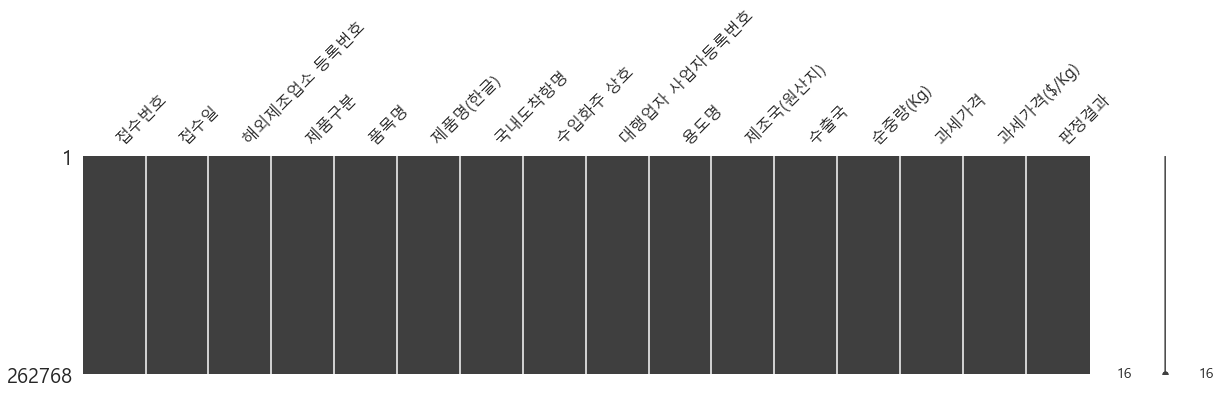

In [264]:
import missingno as msn
plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
msn.matrix(df, figsize=(20,4))

## Step 1. 점검과 위반 건수 반영
- 간단하게 적합은 부적합을 제외한 모든 값

In [266]:
df['점검'] = 1
df['위반'] = 0
df.loc[df['판정결과']== '부적합', '위반'] = 1

df['Date'] = pd.to_datetime(df['접수일'])
df = df.assign(year=df['Date'].dt.year, month=df['Date'].dt.month)

df['Date'].min(), df['Date'].max()
df['Date'].dt.year.value_counts()

df.head()

(Timestamp('2017-09-29 09:08:21'), Timestamp('2021-09-29 12:11:46'))

2018    69060
2019    66617
2020    62015
2021    49021
2017    16055
Name: Date, dtype: int64

,접수번호,접수일,해외제조업소 등록번호,제품구분,품목명,제품명(한글),국내도착항명,수입화주 상호,대행업자 사업자등록번호,용도명,...,수출국,순중량(Kg),과세가격,과세가격($/Kg),판정결과,점검,위반,Date,year,month
188741,201700426825,2017-11-16 11:44:44,CN000003850,가공식품,배추김치,가을아침김치,Pyongtaek,주식회사 씨앤케이푸드,1.212136e+09,판매용,...,중국,4000.00,1600.0,0.400,0.0,1,0,2017-11-16 11:44:44,2017,11
188748,201700418139,2017-11-10 10:17:22,JP000001037,가공식품,즉석조리식품,포르치니버섯 스프,Pusan,한국아지노모도(주),2.118746e+09,판매용,...,일본,9430.20,108416.0,11.497,0.0,1,0,2017-11-10 10:17:22,2017,11
188751,201700434258,2017-11-22 10:30:29,JP000003697,가공식품,마요네즈,큐피 마요네즈,Pusan,매크로통상(주),1.268169e+09,판매용,...,일본,70.00,344.0,4.914,0.0,1,0,2017-11-22 10:30:29,2017,11
188753,201700453164,2017-12-06 09:18:36,MX000000334,가공식품,캔디류(사탕),미니유니콘팝버블검향,Pusan,(주)씨믹스,1.910200e+09,판매용,...,미국,112.32,1404.0,12.500,0.0,1,0,2017-12-06 09:18:36,2017,12
188754,201700383852,2017-10-18 10:11:10,JP000001862,가공식품,당류가공품,타라마 분말흑당,인천공항,투웨이인터내셔널,1.218176e+09,판매용,...,일본,80.00,540.7,6.759,0.0,1,0,2017-10-18 10:11:10,2017,10


# 업체별(제조업체, 대행업체, 수입화주별) 시간별(년도, 월, 분기 등) 시계열형테의 파생변수 만들기

In [267]:
def convert_time_unfit(df) : 
    df20 = df.groupby(['해외제조업소 등록번호', 'year']).agg({'점검':['sum'], '위반':['sum']})
    df20.columns = ['점검', '위반']
    df20 = df20.reset_index()

    from itertools import product
    df30 = pd.DataFrame(product(df['해외제조업소 등록번호'].unique(), df['year'].unique()), columns=['해외제조업소 등록번호','year'])

    df31 = (df30.merge(df20, how='left').sort_values(['해외제조업소 등록번호','year']).reset_index(drop=True))
    df32 = pd.DataFrame()
    lags = range(1, 6)
    cols = ['점검', '위반']
    for n in lags: 
        for col in cols:
            df32[f'{col} (n-{n})'] = df31.groupby(['해외제조업소 등록번호'])[f'{col}'].shift(n)
    df_A = df31.merge(df32, left_index=True, right_index=True)

    df41 = df.sort_values(['해외제조업소 등록번호','Date']).reset_index(drop=True)
    df42 = df41.groupby(['해외제조업소 등록번호','year']).agg({'점검':'cumsum', '위반':'cumsum'})
    df43 = df41.merge(df42, left_index=True, right_index=True)
    df43['점검_y'] = df43['점검_y'] - df43['점검_x']
    df43['위반_y'] = df43['위반_y'] - df43['위반_x']
    del df43['점검_x']
    df_B = df43.rename(columns={'점검_y':'점검', '위반_y':'위반', '위반_x':'점검결과'})

    df = df_B.merge(df_A, on=['해외제조업소 등록번호', 'year'])
    del df['점검_y']; del df['위반_y']

    check = ['점검 (n-1)', '위반 (n-1)', '점검 (n-2)', '위반 (n-2)', '점검 (n-3)',
             '위반 (n-3)', '점검 (n-4)', '위반 (n-4)', '점검 (n-5)', '위반 (n-5)']
    for i in check :
        df[i]= df[i].fillna(0)
        
    df.head()
    
    return df

In [268]:
df = convert_time_unfit(df)
df

,접수번호,접수일,해외제조업소 등록번호,제품구분,품목명,제품명(한글),국내도착항명,수입화주 상호,대행업자 사업자등록번호,용도명,...,점검 (n-1),위반 (n-1),점검 (n-2),위반 (n-2),점검 (n-3),위반 (n-3),점검 (n-4),위반 (n-4),점검 (n-5),위반 (n-5)
0,201700427335,2017-11-17 09:10:31,AE000000003,가공식품,초콜릿가공품,티파니 브레이크,Pusan,(주)제이앤에스글로벌,1.268169e+09,판매용,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,201700427336,2017-11-17 09:10:55,AE000000003,가공식품,초콜릿가공품,티파니 브레이크 수파,Pusan,(주)제이앤에스글로벌,1.268169e+09,판매용,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,201800040692,2018-01-30 10:24:24,AE000000003,가공식품,초콜릿가공품,티파니 브레이크,Pusan,(주)제이앤에스글로벌,1.268169e+09,판매용,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,201800040788,2018-01-30 10:33:08,AE000000003,가공식품,초콜릿가공품,티파니 브레이크 수파,Pusan,(주)제이앤에스글로벌,1.268169e+09,판매용,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,201800240633,2018-06-19 09:36:53,AE000000003,가공식품,곡류가공품,비스퀵 컴플리트 허니버터 비스킷 믹스,Pusan,제너럴밀스코리아(주),1.228542e+09,판매용,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262763,202100447294,2021-07-14 09:56:42,ZA000001951,가공식품,침출차,프레시팍 루이보스 티,Inchon,차차티,2.062083e+09,판매용,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
262764,201700478445,2017-12-22 11:00:11,ZM000000002,가공식품,벌꿀,벌꿀,인천공항,NS 바이오,1.218183e+09,판매용,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
262765,201900056085,2019-02-11 09:44:49,ZM000000002,가공식품,벌꿀,벌꿀,인천공항,NS 바이오,7.330501e+09,판매용,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
262766,202100581573,2021-09-10 14:39:54,ZM000000002,가공식품,벌꿀,벌꿀,인천공항,NS 바이오,7.210502e+09,판매용,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# 4. Categorical Encoders

In [269]:
df.columns

Index(['접수번호', '접수일', '해외제조업소 등록번호', '제품구분', '품목명', '제품명(한글)', '국내도착항명',
       '수입화주 상호', '대행업자 사업자등록번호', '용도명', '제조국(원산지)', '수출국', '순중량(Kg)', '과세가격',
       '과세가격($/Kg)', '판정결과', '점검결과', 'Date', 'year', 'month', '점검_x', '위반_x',
       '점검 (n-1)', '위반 (n-1)', '점검 (n-2)', '위반 (n-2)', '점검 (n-3)', '위반 (n-3)',
       '점검 (n-4)', '위반 (n-4)', '점검 (n-5)', '위반 (n-5)'],
      dtype='object')

In [270]:
df.drop(['접수번호', '접수일', '해외제조업소 등록번호', '제품구분', '제품명(한글)', '국내도착항명',
       '수입화주 상호', '대행업자 사업자등록번호', '수출국', '점검결과', 'Date', 'year', 'month', ], axis=1, inplace=True)

In [271]:
df.head()

,품목명,용도명,제조국(원산지),순중량(Kg),과세가격,과세가격($/Kg),판정결과,점검_x,위반_x,점검 (n-1),위반 (n-1),점검 (n-2),위반 (n-2),점검 (n-3),위반 (n-3),점검 (n-4),위반 (n-4),점검 (n-5),위반 (n-5)
0,초콜릿가공품,판매용,아랍에미리트,17142.00,59980.8,3.499,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,초콜릿가공품,판매용,아랍에미리트,13738.00,49671.6,3.616,0.0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,초콜릿가공품,판매용,아랍에미리트,24909.12,84369.6,3.387,0.0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,초콜릿가공품,판매용,아랍에미리트,21254.40,74390.4,3.500,0.0,1,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,곡류가공품,판매용,아랍에미리트,8830.08,15926.4,1.804,0.0,2,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [272]:
df['품목_tm'] = df['품목명'].map(df.groupby('품목명')['판정결과'].mean())

import category_encoders as ce
woe = ce.woe.WOEEncoder()
cat = ce.cat_boost.CatBoostEncoder()
tm = ce.target_encoder.TargetEncoder()
df['국가_woe'] = tm.fit_transform(df['제조국(원산지)'], df.판정결과)

In [273]:
double_tm = df.groupby(['제조국(원산지)', '품목명'])['판정결과'].mean().reset_index()
double_tm.columns = ['제조국(원산지)', '품목명', '국가_품목tm']

In [274]:
df = df.merge(double_tm, on = ['제조국(원산지)', '품목명'], how='left')
df.head()

,품목명,용도명,제조국(원산지),순중량(Kg),과세가격,과세가격($/Kg),판정결과,점검_x,위반_x,점검 (n-1),...,위반 (n-2),점검 (n-3),위반 (n-3),점검 (n-4),위반 (n-4),점검 (n-5),위반 (n-5),품목_tm,국가_woe,국가_품목tm
0,초콜릿가공품,판매용,아랍에미리트,17142.00,59980.8,3.499,0.0,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003787,0.019108,0.0
1,초콜릿가공품,판매용,아랍에미리트,13738.00,49671.6,3.616,0.0,1,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003787,0.019108,0.0
2,초콜릿가공품,판매용,아랍에미리트,24909.12,84369.6,3.387,0.0,0,0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003787,0.019108,0.0
3,초콜릿가공품,판매용,아랍에미리트,21254.40,74390.4,3.500,0.0,1,0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003787,0.019108,0.0
4,곡류가공품,판매용,아랍에미리트,8830.08,15926.4,1.804,0.0,2,0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.014295,0.019108,0.0


In [290]:
df.columns

Index(['품목명', '용도명', '제조국(원산지)', '순중량(Kg)', '과세가격', '과세가격($/Kg)', '판정결과',
       '점검_x', '위반_x', '점검 (n-1)', '위반 (n-1)', '점검 (n-2)', '위반 (n-2)',
       '점검 (n-3)', '위반 (n-3)', '점검 (n-4)', '위반 (n-4)', '점검 (n-5)', '위반 (n-5)',
       '품목_tm', '국가_woe', '국가_품목tm'],
      dtype='object')

In [294]:
X = df.drop(['품목명', '용도명', '제조국(원산지)', '판정결과'], axis=1)
y = df['판정결과']

feature_name = X.columns; best_features = 15

In [295]:
def corr_selector(X, y):

    cor_list = []
    for i in X.columns:
        cor = np.corrcoef(X[i], y)[0, 1]
        cor_list.append(cor)
    cor_feature = X.iloc[:, np.argsort(np.abs(cor_list))[best_features*-1:]].columns.tolist()
    cor_support = [True if i in cor_feature else False for i in feature_name]

    return cor_feature, cor_support 
corr_feature, corr_support = corr_selector(X, y)
'/'.join(corr_feature)
''.join(str(corr_support))

'점검 (n-4)/점검 (n-3)/점검 (n-2)/점검_x/점검 (n-1)/국가_woe/품목_tm/국가_품목tm/위반 (n-1)/위반 (n-4)/점검 (n-5)/위반 (n-5)/위반_x/위반 (n-3)/위반 (n-2)'

'[False, False, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]'

In [296]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

def Chi_selector(X, y):
    chi_selector = SelectKBest(chi2, k=best_features)
    X_norm = MinMaxScaler().fit_transform(X)
    chi_selector.fit(X_norm, y)
    chi_support = chi_selector.get_support()
    chi_feature = X.loc[:, chi_support].columns.tolist()
    return chi_feature, chi_support
chi_feature, chi_support = Chi_selector(X, y)

','.join(chi_feature)
''.join(str(chi_support))

'순중량(Kg),과세가격,과세가격($/Kg),점검_x,점검 (n-1),점검 (n-2),점검 (n-3),위반 (n-3),점검 (n-4),위반 (n-4),점검 (n-5),위반 (n-5),품목_tm,국가_woe,국가_품목tm'

'[ True  True  True  True False  True False  True False  True  True  True\n  True  True  True  True  True  True]'

In [297]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

def Wrapper_RFE(X, y):
    rfe_selector= RFE(estimator= LogisticRegression(), n_features_to_select=best_features, step=20)
    X_norm = MinMaxScaler().fit_transform(X)
    rfe_selector.fit(X_norm, y)
    rfe_support = rfe_selector.get_support()
    rfe_feature = X.loc[:,rfe_support].columns.tolist()

    return rfe_support, rfe_feature

rfe_support, rfe_feature = Wrapper_RFE(X, y)
'/'.join(rfe_feature)
''.join(str(rfe_support))

'순중량(Kg)/과세가격/과세가격($/Kg)/점검_x/점검 (n-1)/위반 (n-1)/점검 (n-2)/점검 (n-3)/위반 (n-3)/점검 (n-4)/위반 (n-4)/점검 (n-5)/품목_tm/국가_woe/국가_품목tm'

'[ True  True  True  True False  True  True  True False  True  True  True\n  True  True False  True  True  True]'

In [299]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

def logistic_regression(X, y):
    embeded_lr2_selector = SelectFromModel(LogisticRegression(), threshold='1.25*median') 
    X_norm = MinMaxScaler().fit_transform(X)
    embeded_lr2_selector.fit(X_norm, y)
    embeded_lr2_support = embeded_lr2_selector.get_support()
    embeded_lr2_feature = X.loc[:,embeded_lr2_support].columns.tolist()
    return embeded_lr2_support, embeded_lr2_feature
embeded_lr2_support, embeded_lr2_feature = logistic_regression(X, y)
'/'.join(embeded_lr2_feature)

def random_forest(X, y):
    
    embeded_rf_selector= SelectFromModel(RandomForestClassifier(), threshold='median')
    embeded_rf_selector.fit(X, y)
    embeded_rf_support = embeded_rf_selector.get_support()
    embeded_rf_feature = X.loc[:,embeded_rf_support].columns.tolist()
    
    return embeded_rf_support, embeded_rf_feature

embeded_rf_support, embeded_rf_feature = random_forest(X, y)
'/'.join(embeded_rf_feature)

'점검_x/점검 (n-1)/점검 (n-2)/점검 (n-4)/품목_tm/국가_woe/국가_품목tm'

'순중량(Kg)/과세가격/과세가격($/Kg)/점검_x/점검 (n-1)/점검 (n-2)/품목_tm/국가_woe/국가_품목tm'

In [300]:
feature_list = pd.DataFrame({'Feature_name':feature_name, 'Pearson':corr_support, 
                             'Chi-2':chi_support, 'RFE':rfe_support, 
                             'Logit_L2':embeded_lr2_support, 'Random Fo':embeded_rf_support
                          })
feature_list['total'] = np.sum(feature_list, axis=1)
feature_list = feature_list.sort_values(['total','Feature_name'] , ascending=False)
feature_list.index = range(1, len(feature_list)+1)
feature_list

,Feature_name,Pearson,Chi-2,RFE,Logit_L2,Random Fo,total
1,품목_tm,True,True,True,True,True,5
2,점검_x,True,True,True,True,True,5
3,점검 (n-2),True,True,True,True,True,5
4,점검 (n-1),True,True,True,True,True,5
5,국가_품목tm,True,True,True,True,True,5
6,국가_woe,True,True,True,True,True,5
7,점검 (n-4),True,True,True,True,False,4
8,점검 (n-5),True,True,True,False,False,3
9,점검 (n-3),True,True,True,False,False,3
10,위반 (n-4),True,True,True,False,False,3


<AxesSubplot:xlabel='Feature_name'>

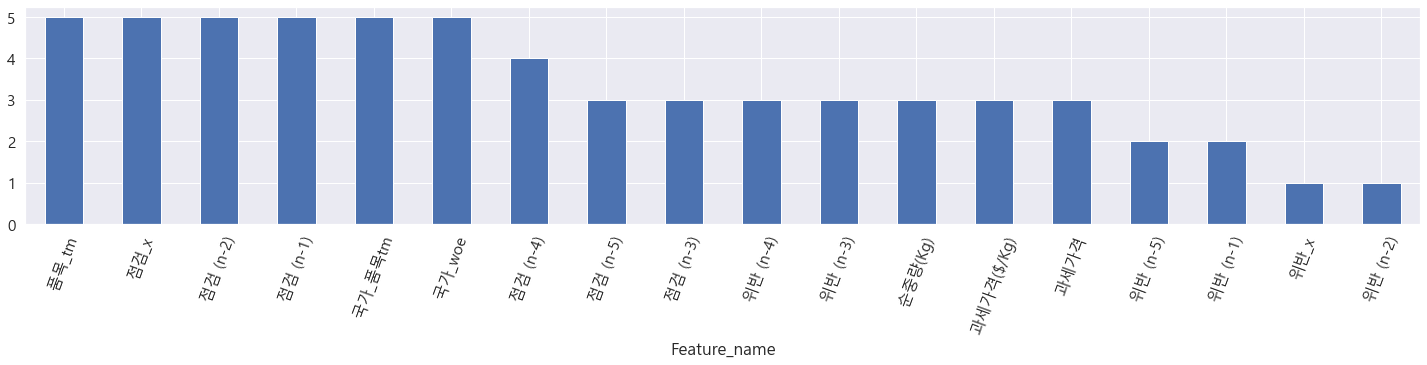

In [302]:
feature = feature_list.set_index('Feature_name')
plt.rcParams['font.family']='Malgun Gothic'
pd.DataFrame(feature).total.plot(kind='bar', rot = '70', figsize = (25, 4))

In [303]:
feature.shape
feature_select = feature[feature['total'] >= 3]
feature_select.shape
feature_select.index

(18, 6)

(14, 6)

Index(['품목_tm', '점검_x', '점검 (n-2)', '점검 (n-1)', '국가_품목tm', '국가_woe',
       '점검 (n-4)', '점검 (n-5)', '점검 (n-3)', '위반 (n-4)', '위반 (n-3)', '순중량(Kg)',
       '과세가격($/Kg)', '과세가격'],
      dtype='object', name='Feature_name')

In [304]:
X.shape
X = X[feature_select.index]

(262768, 18)

<AxesSubplot:>

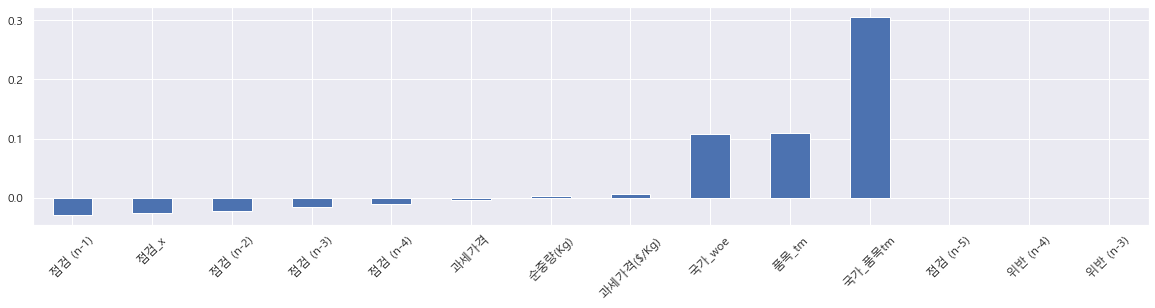

In [305]:
plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
plt.rcParams['axes.unicode_minus'] = False
(X.corrwith(y).sort_values().plot.bar(figsize = (20, 4), 
                                      fontsize = 12, rot = 45, grid = True))

In [306]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size = 0.2, random_state=12)

0.9892681812992351

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     51957
         1.0       0.61      0.15      0.24       597

    accuracy                           0.99     52554
   macro avg       0.80      0.57      0.62     52554
weighted avg       0.99      0.99      0.99     52554



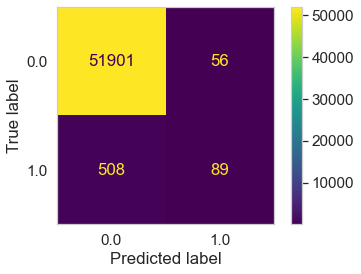

In [307]:
from sklearn import ensemble 
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
# 성능지표
from sklearn.metrics import accuracy_score, plot_roc_curve
from sklearn.metrics import plot_confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
# 파이프라인
from sklearn.pipeline import Pipeline, make_pipeline
# 시각화 툴
import scikitplot as skplt
rf = ensemble.RandomForestClassifier(random_state=11)
#rf = ensemble.RandomForestClassifier(random_state=11, class_weight='balanced') # data.drop(['업소명','등록', '수입거부', '수입중단', '등록취소'], axis=1, inplace=True)
y_predict = rf.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)

### 0.  Ensemble of samplers
- Classifier including inner balancing samplers

array([0.53004043, 0.53546991])

BaggingClassifier(base_estimator=DecisionTreeClassifier(), random_state=0)

AUROC: 0.7481981057071128
AP: 0.2025468651708088
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     51957
         1.0       0.52      0.15      0.23       597

    accuracy                           0.99     52554
   macro avg       0.76      0.57      0.61     52554
weighted avg       0.98      0.99      0.99     52554





array([0.63525857, 0.70891755])

RUSBoostClassifier(n_estimators=200, random_state=0)

AUROC: 0.8085858686971822
AP: 0.05855619151861588
              precision    recall  f1-score   support

         0.0       0.99      0.77      0.87     51957
         1.0       0.03      0.64      0.06       597

    accuracy                           0.77     52554
   macro avg       0.51      0.71      0.46     52554
weighted avg       0.98      0.77      0.86     52554





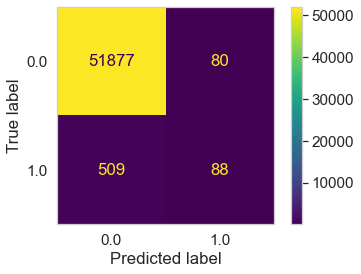

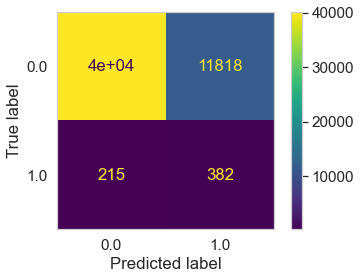

In [308]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import RUSBoostClassifier
from sklearn.model_selection import KFold

bag = BaggingClassifier(base_estimator=DecisionTreeClassifier(), random_state=0) 
brf = BalancedRandomForestClassifier(n_estimators=100, random_state=0)
rusboost = RUSBoostClassifier(n_estimators=200, algorithm='SAMME.R',
                              random_state=0)

kf = KFold(n_splits=2)

for classifier in [bag, rusboost] :
    
    cross_val_score(classifier, X, y, scoring='recall_macro', cv=kf)
    classifier.fit(X_train, y_train)
    y_predict = classifier.predict(X_test)
    y_proba = classifier.predict_proba(X_test)
    print(f'AUROC: {roc_auc_score(y_test, y_proba[:, 1])}')
    print(f'AP: {average_precision_score(y_test, y_proba[:, 1])}')
    print(classification_report(y_test, y_predict))
    print('\n')
    plot_confusion_matrix(classifier, X_test, y_test)

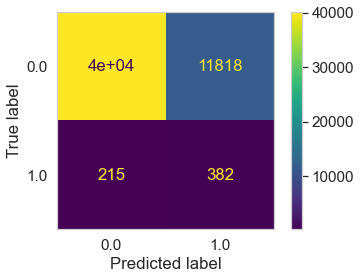

In [309]:
plot_confusion_matrix(classifier, X_test, y_test)

(array([7.28839408e-03, 0.00000000e+00, 9.71785878e-03, 2.01888516e+00,
        1.40374470e+01, 5.46629556e-02, 4.82491688e+00, 4.26030929e+01,
        2.81817904e-01, 1.21473235e-03]),
 array([0.38353656, 0.39920096, 0.41486536, 0.43052975, 0.44619415,
        0.46185854, 0.47752294, 0.49318733, 0.50885173, 0.52451612,
        0.54018052]),
 <BarContainer object of 10 artists>)

(array([1.21473235e-03, 2.81817904e-01, 4.26030929e+01, 4.82491688e+00,
        5.46629556e-02, 1.40374470e+01, 2.01888516e+00, 9.71785878e-03,
        0.00000000e+00, 7.28839408e-03]),
 array([0.45981948, 0.47548388, 0.49114827, 0.50681267, 0.52247706,
        0.53814146, 0.55380585, 0.56947025, 0.58513464, 0.60079904,
        0.61646344]),
 <BarContainer object of 10 artists>)

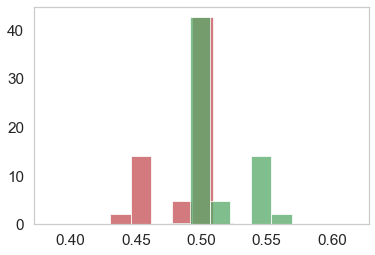

In [310]:
plt.hist(y_proba[:, 1], density=True, facecolor='r', alpha=0.75) 
plt.hist(y_proba[:, 0], density=True, facecolor='g', alpha=0.75) 

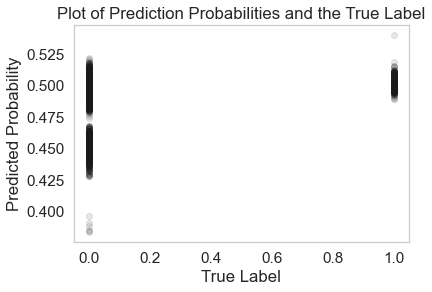

In [311]:
data = pd.DataFrame(np.c_[y_proba[:,1], y_test], columns=['Predicted Probability','True Label'])
ax = sns.regplot(x="True Label", y="Predicted Probability", color='k', 
                 fit_reg=False, scatter_kws={'alpha':0.1},
                 data=data).set_title('Plot of Prediction Probabilities and the True Label')

<AxesSubplot:title={'center':'Lift Curve'}, xlabel='Percentage of sample', ylabel='Lift'>

<AxesSubplot:title={'center':'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

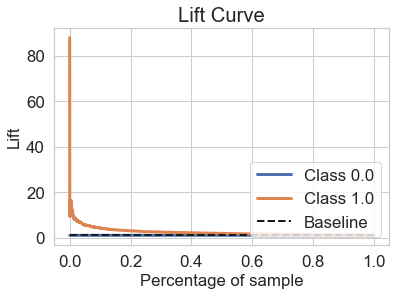

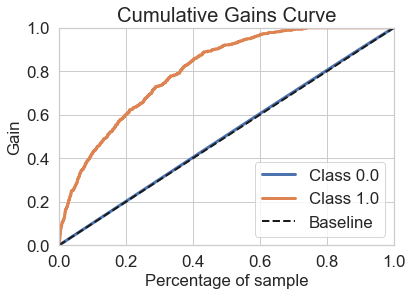

In [312]:
skplt.metrics.plot_lift_curve(y_test, y_proba)
skplt.metrics.plot_cumulative_gain(y_test, y_proba)

<AxesSubplot:title={'center':'KS Statistic Plot'}, xlabel='Threshold', ylabel='Percentage below threshold'>

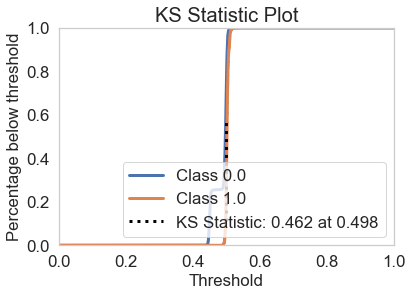

In [313]:
skplt.metrics.plot_ks_statistic(y_test, y_proba)

<AxesSubplot:title={'center':'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

<AxesSubplot:title={'center':'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>

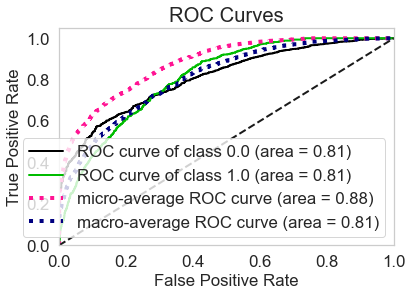

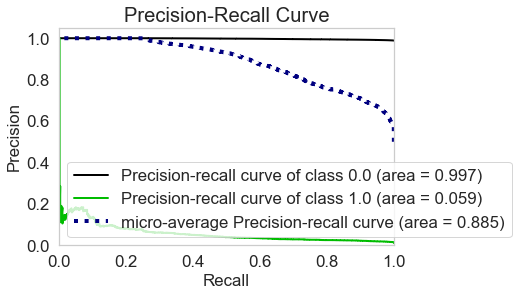

In [314]:
skplt.metrics.plot_roc(y_test, y_proba)
skplt.metrics.plot_precision_recall(y_test, y_proba)

In [315]:
from sklearn.metrics import precision_recall_curve
def to_labels(pos_probs, threshold):
    return (pos_probs >= threshold).astype('int')
p, r, thresholds = precision_recall_curve(y_test, y_proba[:, 1])
scores = [np.sum(to_labels(y_proba[:, 1], t))/len(y_proba[:, 1]) for t in thresholds]

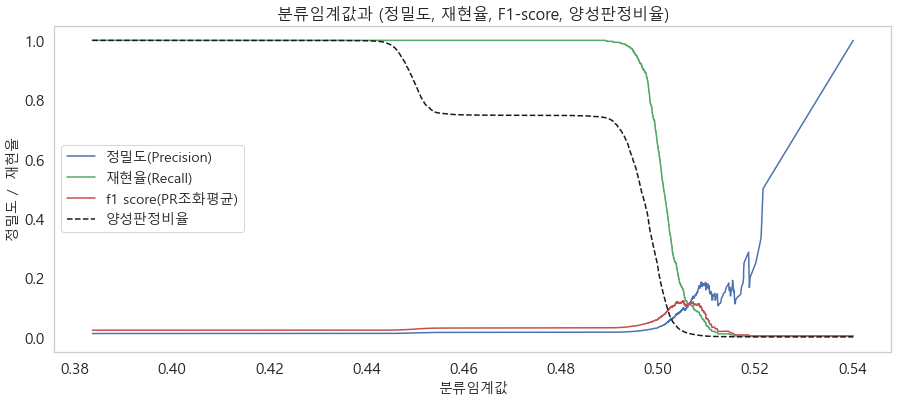

In [316]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds): 
    plt.rcParams["figure.figsize"] = (15,6)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    plt.title('분류임계값과 (정밀도, 재현율, F1-score, 양성판정비율)', fontsize='16') 
    plt.plot(thresholds, precisions[:-1], 'b-', label='정밀도(Precision)') # 판사
    plt.plot(thresholds, recalls[:-1], 'g-', label='재현율(Recall)') # 검사
    plt.plot(thresholds, (2*precisions[:-1]*recalls[:-1])/(precisions[:-1] +recalls[:-1]), 
             'r-', label='f1 score(PR조화평균)') # 변호사
    plt.plot(thresholds, scores, 'k--', label='양성판정비율') # q-ratio
    plt.ylabel('정밀도 /  재현율', fontsize='14') 
    plt.xlabel('분류임계값', fontsize='14') 
    plt.legend(loc='best', fontsize='14') 
plot_precision_recall_vs_threshold(p, r, thresholds)

  0%|          | 0/1 [00:00<?, ?it/s]

<AxesSubplot:title={'center':'Calibration plots (Reliability Curves)'}, xlabel='Mean predicted value', ylabel='Fraction of positives'>

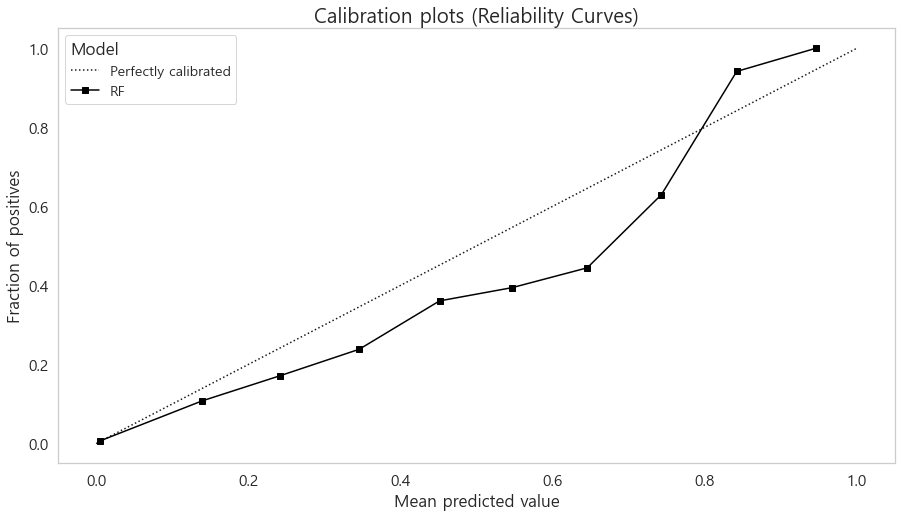

In [317]:
classifiers = {}
#classifiers.update({'GNB': GaussianNB()})
#classifiers.update({'LGR': LogisticRegression(class_weight='balanced')})
#classifiers.update({'SVC': SVC(probability=True)})
classifiers.update({'RF': ensemble.RandomForestClassifier(n_estimators=100, class_weight='balanced')})
from tqdm import tqdm_notebook
classifier_labels = []
probas_list = []
for classifier_label, classifier in tqdm_notebook(classifiers.items()):
    y_proba = classifier.fit(X_train, y_train).predict_proba(X_test)
    probas_list.append(y_proba)
    classifier_labels.append(classifier_label)

skplt.metrics.plot_calibration_curve(y_test, probas_list, classifier_labels, figsize=(15,8))
leg = plt.legend(title='Model', fontsize = 14)
leg._legend_box.align = 'left'

### 1. Decision tree

In [318]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
params = {
    'criterion' :['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth' : np.arange(1,15),
    'min_samples_split': np.arange(0.005, 0.1, 0.001),
    'min_samples_leaf': [0.005, 0.01, 0.05, 0.10], # np.arange(0.005, 0.1, 0.001)
    'max_features': ['auto', 'sqrt', 'log2'],
}

np.random.seed(1111)
kf = KFold(n_splits=2)
model = DecisionTreeClassifier(random_state=11)
grid = RandomizedSearchCV(model, params, cv=kf, n_iter=50, 
                          scoring = 'recall_macro', verbose =True)
grid.fit(X_train, y_train)
print(f'optimal parameter: {grid.best_params_}')

y_predict = grid.predict(X_test)
print(classification_report(y_test, y_predict))

Fitting 2 folds for each of 50 candidates, totalling 100 fits


RandomizedSearchCV(cv=KFold(n_splits=2, random_state=None, shuffle=False),
                   estimator=DecisionTreeClassifier(random_state=11), n_iter=50,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [0.005, 0.01, 0.05,
                                                             0.1],
                                        'min_samples_split': array([0.005,...
       0.05 , 0.051, 0.052, 0.053, 0.054, 0.055, 0.056, 0.057, 0.058,
       0.059, 0.06 , 0.061, 0.062, 0.063, 0.064, 0.065, 0.066, 0.067,
       0.068, 0.069, 0.07 , 0.071, 0.072, 0.073, 0.074, 0.075, 0.076,
       0.077, 0.078, 0.079, 0.08 , 0.081, 0.082, 0.083, 0.084, 0.085,
       0.086, 0.087, 0.088, 0.089, 0.09 , 0.091, 0.092, 0.093, 0.094,
       0.095, 0.096, 0.097, 0.098, 0.099]),
                                        'splitter': ['best', 'random']},
                   scoring='recall_macro', verbose=True)

optimal parameter: {'splitter': 'best', 'min_samples_split': 0.07700000000000001, 'min_samples_leaf': 0.05, 'max_features': 'auto', 'max_depth': 13, 'criterion': 'entropy'}
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     51957
         1.0       0.00      0.00      0.00       597

    accuracy                           0.99     52554
   macro avg       0.49      0.50      0.50     52554
weighted avg       0.98      0.99      0.98     52554



In [319]:
from sklearn import ensemble 
stump= DecisionTreeClassifier(max_depth=1, random_state=1357)
bag = ensemble.BaggingClassifier(stump, n_estimators = 500, max_samples =0.8)
y_predict = bag.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))

0.9886402557369562

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     51957
         1.0       0.00      0.00      0.00       597

    accuracy                           0.99     52554
   macro avg       0.49      0.50      0.50     52554
weighted avg       0.98      0.99      0.98     52554



### 2 . Bagging

In [320]:
dt = DecisionTreeClassifier(random_state=11)
bag = ensemble.BaggingClassifier(dt, n_estimators = 30, max_samples =0.8)
y_predict = bag.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))

0.9890779008258173

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     51957
         1.0       0.59      0.13      0.22       597

    accuracy                           0.99     52554
   macro avg       0.79      0.57      0.61     52554
weighted avg       0.99      0.99      0.99     52554



In [321]:
dt = DecisionTreeClassifier(random_state=11)
bag = ensemble.BaggingClassifier(dt, n_estimators = 100, max_samples =0.8)
y_predict = bag.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))

y_proba = bag.predict_proba(X_test)
print(f'AUROC: {roc_auc_score(y_test, y_proba[:, 1])}')
print(f'AP: {average_precision_score(y_test, y_proba[:, 1])}')

0.9889827605891084

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     51957
         1.0       0.56      0.14      0.23       597

    accuracy                           0.99     52554
   macro avg       0.77      0.57      0.61     52554
weighted avg       0.99      0.99      0.99     52554

AUROC: 0.8576078840352748
AP: 0.2500955590186045


In [322]:
dt = DecisionTreeClassifier(random_state=11)
bag = ensemble.BaggingClassifier(dt, n_estimators = 300, max_samples =0.8)
y_predict = bag.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))

0.9890208166837919

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     51957
         1.0       0.57      0.14      0.22       597

    accuracy                           0.99     52554
   macro avg       0.78      0.57      0.61     52554
weighted avg       0.99      0.99      0.99     52554



### 3. Random Forest

In [323]:
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 100, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(5, 20, 10)]
min_samples_split = np.arange(2, 30, 2)
min_samples_leaf = np.arange(2, 50, 2)
bootstrap = [True, False]
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

from sklearn.metrics import roc_auc_score, average_precision_score
np.random.seed(4321)
rf = ensemble.RandomForestClassifier(random_state=11)
rf_random = RandomizedSearchCV(rf, random_grid, cv=kf, scoring = 'recall')
y_predict = rf_random.fit(X_train, y_train).predict(X_test)
print(classification_report(y_test, y_predict))
y_proba = rf_random.predict_proba(X_test)
print(f'정확도(accuracy): {accuracy_score(y_test, y_predict)}')
print(f'AUROC: {roc_auc_score(y_test, y_proba[:, 1])}')
print(f'AP: {average_precision_score(y_test, y_proba[:, 1])}')

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     51957
         1.0       0.69      0.07      0.12       597

    accuracy                           0.99     52554
   macro avg       0.84      0.53      0.56     52554
weighted avg       0.99      0.99      0.98     52554

정확도(accuracy): 0.9890779008258173
AUROC: 0.8972631149795336
AP: 0.23739376931714098


### 4. Extremely Randomized Trees

In [324]:
extree = ensemble.ExtraTreesClassifier(random_state=0)
y_predict = extree.fit(X_train, y_train).predict(X_test)
print(classification_report(y_test, y_predict))
y_proba = extree.predict_proba(X_test)
print(f'정확도(accuracy): {accuracy_score(y_test, y_predict)}')
print(f'AUROC: {roc_auc_score(y_test, y_proba[:, 1])}')
print(f'AP: {average_precision_score(y_test, y_proba[:, 1])}')

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     51957
         1.0       0.43      0.19      0.27       597

    accuracy                           0.99     52554
   macro avg       0.71      0.60      0.63     52554
weighted avg       0.98      0.99      0.99     52554

정확도(accuracy): 0.9879171899379686
AUROC: 0.8292419781865104
AP: 0.232301938357615


### 5. VotingClassifier

In [325]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

estimators=[('lgr', LogisticRegression(solver='saga', class_weight='balanced')),
            ('rf',  ensemble.RandomForestClassifier(class_weight='balanced')),
            ('gnb', GaussianNB())]
            
eclf = ensemble.VotingClassifier(estimators, voting='soft')

params = {
    'lgr__C': [0.01, 0.1, 1, 10], 'lgr__penalty': ['l1', 'l2'], 
    'rf__n_estimators': [200], 'rf__max_features': ['auto', 'sqrt', 'log2'],
    'rf__max_depth' : [3, 4, 5, 6, 7, 8], 'rf__criterion' :['gini', 'entropy'],
    'gnb__var_smoothing': [1e-9, 1e-8,1e-7, 1e-6, 1e-5]
}

kf = KFold(n_splits=5)
grid = RandomizedSearchCV(eclf, params, cv = kf,  verbose = 1, n_iter = 5,
                          scoring = 'f1_macro')           
      
y_predict = grid.fit(X_train, y_train).predict(X_test)
y_proba = grid.predict_proba(X_test)
print(f'AUROC: {roc_auc_score(y_test, y_proba[:, 1])}')
print(f'AP: {average_precision_score(y_test, y_proba[:, 1])}')
print(classification_report(y_test, y_predict))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
AUROC: 0.8678363847388426
AP: 0.08604782173373682
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     51957
         1.0       0.17      0.06      0.08       597

    accuracy                           0.99     52554
   macro avg       0.58      0.53      0.54     52554
weighted avg       0.98      0.99      0.98     52554



### 6. StackingClassifier

In [326]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier 
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler 
from sklearn.pipeline import make_pipeline 

In [ ]:
estimators = [
    ('bag', ensemble.BaggingClassifier(dt, n_estimators = 100, max_samples =0.8)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=5)),
    ('gnb', grid)
]

meta = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression()) 

y_predict = meta.fit(X_train, y_train).predict(X_test)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [ ]:
y_proba = meta.predict_proba(X_test)
print(f'AUROC: {roc_auc_score(y_test, y_proba[:, 1])}')
print(f'AP: {average_precision_score(y_test, y_proba[:, 1])}')
print(classification_report(y_test, y_predict))

### 7. Catboost Classifier

In [ ]:
from catboost import CatBoostClassifier
seed =1234
params = {'loss_function':'Logloss', 'eval_metric':'Recall', 
          'verbose': 200, 'random_seed': seed}
          
cbc_1 = CatBoostClassifier(**params)

cbc_1.fit(X_train, y_train, 
          eval_set=(X_test, y_test), 
          plot=True)

y_predict = cbc_1.predict(X_test)

y_proba = cbc_1.predict_proba(X_test)
print(f'AUROC: {roc_auc_score(y_test, y_proba[:, 1])}')
print(f'AP: {average_precision_score(y_test, y_proba[:, 1])}')
print(classification_report(y_test, y_predict))

# End